# Notebook 1 — CatBoost Direct Multi-Output Forecasting
## Framing Time Series as Tabular Regression

**Learning Goals for This Notebook**
- Understand why and how we can turn a time-series problem into a standard supervised regression problem
- Build 70+ temporal features from a single target column (no exogenous inputs needed)
- Train 96 independent CatBoost models — one per forecast horizon — using the *direct multi-output* strategy
- Evaluate 96-step-ahead forecasts on a strictly separated test year

---

### The Problem
Predict **Spain's total electricity load 96 hours (4 days) into the future**, using only historical load values and the timestamp. Data covers 2015–2018 at hourly resolution.

### The Tabular Regression Insight

Deep learning models such as LSTMs and Temporal Fusion Transformers treat time series as *sequences* — they require careful architectures to carry information across many time steps.

The **tabular regression approach** takes a different view:

> *A row at time t, together with its engineered temporal features, contains everything needed to predict the future load.*

Each row becomes an independent sample. We extract the temporal context as explicit *columns* — lag values, moving averages, cyclical encodings — and then let a gradient boosting tree handle the rest. No sequential architecture. No backpropagation through time.

| Step | What We Do | Why |
|------|-----------|-----|
| 1 | Extract calendar features | Encode daily / weekly / seasonal repeating patterns |
| 2 | Apply cyclical (sin/cos) encoding | Prevent the "midnight discontinuity" (hour 23 ≠ hour 0 numerically but they are adjacent) |
| 3 | Add lag features | Give the model memory of specific past values |
| 4 | Compute rolling statistics | Summarise recent trend and volatility in a single number |
| 5 | Compute differencing features | Capture the rate of change (momentum) |

---

### Direct Multi-Output Strategy

To predict 96 hours ahead, we train **96 separate CatBoost models**:
- Model k uses features at time t to directly predict **y(t+k)** for k = 1, 2, …, 96
- Because each model targets its own horizon independently, **errors do not accumulate**
- Trade-off: we need to train and store 96 models instead of one

Compare this to Notebook 2, where a *single* model predicts t+1 and is applied recursively.

---

## Step 1 — Import Libraries

We use the following packages:

| Library | Purpose |
|---------|---------|
| `pandas` / `numpy` | Data loading, manipulation, and numerical operations |
| `matplotlib` | Plotting the time series and evaluation charts |
| `catboost` | Gradient-boosted trees — our main forecasting model |
| `scikit-learn` | Evaluation metrics (MAE, RMSE) |
| `tqdm` | Progress bar so we can watch the 96-model training loop |

> **Why CatBoost?** CatBoost uses *ordered boosting* which reduces target leakage in standard gradient boosting, and *symmetric (oblivious) trees* which provide faster, more regularised predictions. It handles NaN natively and works well out-of-the-box with minimal tuning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from typing import List, Union, Optional
from catboost import CatBoostRegressor
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2 — Load Data

We load two CSV files:

- **`energy_data.csv`** — Hourly Spanish electricity grid data (2015–2018): generation by source, total load, wholesale price
- **`weather_data.csv`** — Hourly weather observations (temperature, humidity, wind speed, cloud cover, etc.)

> **Educational note:** In this notebook we deliberately use *only* the `total load actual` column and ignore all weather features. This demonstrates how much signal can be extracted from temporal patterns alone, without any exogenous covariates. Electricity demand is highly predictable from time-of-day and day-of-week patterns — we do not always need external inputs.

In [2]:
# Load CSVs
df_energy = pd.read_csv('Data/energy_data.csv')
df_weather = pd.read_csv('Data/weather_data.csv')

print(f"Energy data shape: {df_energy.shape}")
print(f"Weather data shape: {df_weather.shape}")
print(f"\nEnergy columns: {df_energy.columns.tolist()}")
print(f"\nWeather columns: {df_weather.columns.tolist()}")

Energy data shape: (35064, 17)
Weather data shape: (35064, 12)

Energy columns: ['time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'total load actual', 'price actual']

Weather columns: ['dt_iso', 'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all']


In [3]:
# Preview the data
display(df_energy.head(3))
display(df_weather.head(3))

,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,25385.0,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,24382.0,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,22734.0,64.48


,dt_iso,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all
0,2015-01-01 00:00:00+01:00,270.475,270.475,270.475,1035.000000,77.000000,1.0,62.000000,0.0,0.0,0.0,0.0
1,2015-01-01 01:00:00+01:00,270.475,270.475,270.475,1035.000000,77.000000,1.0,62.000000,0.0,0.0,0.0,0.0
2,2015-01-01 02:00:00+01:00,270.212,270.212,270.212,1035.333333,77.333333,1.0,54.666667,0.0,0.0,0.0,0.0


## Step 3 — Data Preprocessing

Before we can do any feature engineering, we need a clean, gap-free hourly time series.

### What this cell does step by step

1. **Parse timestamps** — both CSVs store time in different column names (`time` vs `dt_iso`). We parse them to timezone-aware UTC datetime objects so they can be aligned correctly across sources.

2. **Set datetime index** — pandas aligns DataFrames on their index during a join. Setting the timestamp as the index ensures rows are matched by the correct timestamps, not by row numbers.

3. **Inner join** — keep only timestamps that appear in *both* the energy and weather data. This drops any orphan rows where one source has data but the other doesn't.

4. **Resample and forward-fill** — the raw data may have irregular gaps (missing hours due to meter outages or reporting delays). We create a complete hourly grid with `date_range` and use `ffill()` to fill any gaps with the most recent known value. This avoids NaN cascades in later rolling features.

5. **Select target** — we keep only `total load actual` (MW). All other columns are discarded because our tabular approach will recreate temporal context from this single column via explicit feature engineering in Step 5.

> **Leakage warning:** `ffill()` is applied to the full series before the train/test split — this is safe because it only fills missing *historical* data gaps, not future values. Be careful with transforms that look forward in time (e.g., forward-looking rolling windows) — those would be leakage.

In [4]:
# Parse and index timestamps
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True, errors='coerce')
df_weather.set_index('dt_iso', inplace=True)

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True, errors='coerce')
df_energy.set_index('time', inplace=True)

# Join on datetime index
df = df_energy.join(df_weather, how='inner')
df.index = pd.to_datetime(df.index, utc=True)

# Resample to consistent hourly frequency and forward-fill gaps
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_index)
df = df.ffill()

# Focus on the target column only (tabular approach — no exogenous weather features)
df = df[['total load actual']]

print(f"Combined dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Combined dataset shape: (35064, 1)
Date range: 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Missing values: 0


## Step 4 — Exploratory Visualization

Before building any model, always look at your data.

In the plot below, look for:
- **Daily cycles**: load is higher during daytime hours and lower at night
- **Weekly cycles**: weekends have a different (generally lower) demand profile than weekdays
- **Seasonal pattern**: Spanish load tends to peak in summer (air conditioning) and winter (heating), with a dip in spring/autumn
- **Anomalies or outliers**: sudden dips might be public holidays or data quality issues

Understanding these patterns will help you appreciate *why* the feature engineering in Step 5 works — we are explicitly encoding these known periodicities as model features.

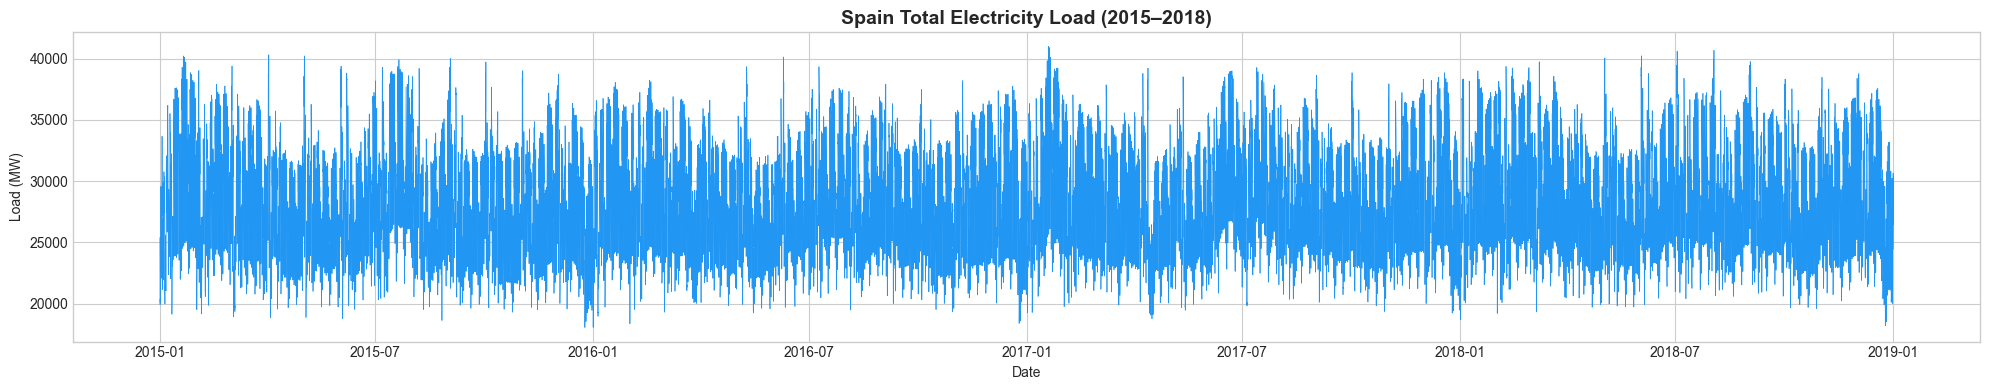


Basic Statistics:


,total load actual
count,35064.0
mean,28697.6
std,4575.9
min,18041.0
25%,24806.8
50%,28902.0
75%,32194.2
max,41015.0


In [5]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df.index, df['total load actual'], linewidth=0.5, color='#2196F3')
ax.set_title('Spain Total Electricity Load (2015–2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print(f"\nBasic Statistics:")
display(df.describe().round(1))

## Step 5 — Feature Engineering

This is the **most important step** in the tabular regression approach. We convert a raw univariate time series into a feature-rich tabular dataset. CatBoost is a powerful learner, but it can only see what we give it — so we encode as much temporal knowledge as possible as explicit columns.

### Feature Catalogue

| Category | Features Created | Key Idea |
|----------|-----------------|---------|
| **Calendar** | `hr`, `mnth`, `weekday`, `week`, `day` | Raw integer positions in time |
| **Cyclical Encoding** | `hr_sin/cos`, `day_sin/cos`, `mnth_sin/cos`, `weekday_sin/cos`, `week_sin/cos` | Wrap circular variables so numerically adjacent values are also temporally adjacent |
| **Lag Features** | past load at t−1, t−3, t−6, …, t−144 h | The model's explicit "memory" of past values |
| **Rolling Means** | 1h, 3h, 6h, …, 144h moving averages | Smoothed load trend at different time scales |
| **Rolling Std Dev** | 12h, 24h, 7d, 30d standard deviations | Demand volatility — high std = erratic week |
| **Differencing** | Δ1h, Δ3h, …, Δ144h | Rate of change — momentum signal |

### Deep Dive: Why Cyclical Encoding?

Consider the raw `hour` feature. Hour 23 and hour 0 are numerically 23 apart, but they are only *one hour apart in reality*. A tree that splits on raw integers will treat midnight as far from 11 PM — causing it to learn separate patterns for the two sides of midnight even though they are adjacent.

Cyclical encoding converts each circular value to a point on the unit circle:

```
hr_sin = sin(2π × hour / 24)
hr_cos = cos(2π × hour / 24)
```

Now hour 23 and hour 0 are close in the (sin, cos) plane. The model sees them as neighbours and can share what it learns about them.

The same principle applies to day-of-month (period 31), month (period 12), day-of-week (period 7), and week-of-year (period 52).

### Deep Dive: Lag vs. Rolling Mean

| Feature type | What it captures | Example |
|---|---|---|
| **Lag at t−k** | The exact value k hours ago | "What was the load at exactly this time yesterday?" |
| **Rolling mean over w hours** | Smoothed trend over the most recent w hours | "What is the average demand level over the past 3 days?" |

Lags give precise historical snapshots. Rolling means filter out noise and reveal the underlying trend. Both are complementary — use both together for best results.

### Result

After this step, each row contains 70+ features. We now have a standard regression dataset.

In [6]:
# --- Step 5a: Extract Calendar Features ---
target_columns = ['total load actual']

df['time'] = df.index
df['time'] = pd.to_datetime(df['time'], utc=True)

df['hr'] = df['time'].dt.hour.values
df['mnth'] = df['time'].dt.month.values
df['weekday'] = df['time'].dt.weekday.values
df['week'] = df['time'].dt.isocalendar().week.values
df['day'] = df['time'].dt.day.values

df.drop(columns=['time'], inplace=True)

print(f"After calendar features: {df.shape[1]} columns")
print(f"Calendar features: hr, mnth, weekday, week, day")

After calendar features: 6 columns
Calendar features: hr, mnth, weekday, week, day


In [7]:
# --- Step 5b: Lag Features, Rolling Statistics, Differencing, and Cyclical Encoding ---

df.loc[:, 'previous_' + target_columns[0]] = df[target_columns[0]]

all_col = df.columns.tolist()
all_col.remove('total load actual')

for feature in all_col:
    # --- Previous load features (lag, rolling MA, rolling std, differencing) ---
    if feature == 'previous_' + target_columns[0]:
        # Rolling Moving Averages (smoothed trend at multiple scales)
        for w in [1, 3, 6, 12, 24, 48, 72]:
            df[feature + f'_ma{w}'] = df[feature].rolling(window=w).mean()
        for i in range(4, 7):
            df[feature + f'_ma{24*i}'] = df[feature].rolling(window=24*i).mean()

        # Lag features (past values at specific offsets)
        for s in [1, 3, 6, 12, 24, 48, 72]:
            df[feature + f'_{s}'] = df[feature].shift(s)
        for i in range(4, 7):
            df[feature + f'_{24*i}'] = df[feature].shift(24*i)

        # Rolling Standard Deviation (volatility signals)
        for w, label in [(12, '12'), (24, '24'), (24*7, '7d'), (24*30, '30d')]:
            df[feature + f'_std_{label}'] = df[feature].rolling(window=w).std()

        # Differencing (rate of change)
        for d in [1, 3, 6, 12, 24, 48, 72]:
            df[feature + f'_diff_{d}'] = df[feature].diff(d)
        for i in range(4, 7):
            df[feature + f'_diff_{24*i}'] = df[feature].diff(24*i)

    # --- Hour features (cyclical + lag + rolling) ---
    if feature == 'hr':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 24)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 24)
        for w in [1, 3, 6, 12, 18]:
            df[feature + f'_ma{w}'] = df[feature].rolling(window=w).mean()
        for s in [1, 3, 6, 12, 18]:
            df[feature + f'_{s}'] = df[feature].shift(s)

    # --- Day features (cyclical + lag + rolling) ---
    if feature == 'day':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 31)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 31)
        for w in [24, 48, 72, 96]:
            df[feature + f'_ma{w}'] = df[feature].rolling(window=w).mean()
        for s in [24, 48, 72, 96]:
            df[feature + f'_{s}'] = df[feature].shift(s)

    # --- Month, Weekday, Week: cyclical encoding only ---
    if feature == 'mnth':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 12)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 12)
    if feature == 'weekday':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 7)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 7)
    if feature == 'week':
        df[feature + '_sin'] = np.sin(2 * np.pi * df[feature] / 52)
        df[feature + '_cos'] = np.cos(2 * np.pi * df[feature] / 52)

print(f"Total features after engineering: {df.shape[1]} columns")
print(f"Total samples: {df.shape[0]:,} rows")

Total features after engineering: 69 columns
Total samples: 35,064 rows


In [8]:
# Preview the engineered feature matrix
print("Feature columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:3d}. {col}")

print(f"\nSample row (last available):")
display(df.tail(1).T)

Feature columns:
    1. total load actual
    2. hr
    3. mnth
    4. weekday
    5. week
    6. day
    7. previous_total load actual
    8. hr_sin
    9. hr_cos
   10. hr_ma1
   11. hr_ma3
   12. hr_ma6
   13. hr_ma12
   14. hr_ma18
   15. hr_1
   16. hr_3
   17. hr_6
   18. hr_12
   19. hr_18
   20. mnth_sin
   21. mnth_cos
   22. weekday_sin
   23. weekday_cos
   24. week_sin
   25. week_cos
   26. day_sin
   27. day_cos
   28. day_ma24
   29. day_ma48
   30. day_ma72
   31. day_ma96
   32. day_24
   33. day_48
   34. day_72
   35. day_96
   36. previous_total load actual_ma1
   37. previous_total load actual_ma3
   38. previous_total load actual_ma6
   39. previous_total load actual_ma12
   40. previous_total load actual_ma24
   41. previous_total load actual_ma48
   42. previous_total load actual_ma72
   43. previous_total load actual_ma96
   44. previous_total load actual_ma120
   45. previous_total load actual_ma144
   46. previous_total load actual_1
   47. previous_total loa

,2018-12-31 22:00:00+00:00
total load actual,24455.0
hr,22
mnth,12
weekday,0
week,1
...,...
previous_total load actual_diff_48,-2877.0
previous_total load actual_diff_72,-3560.0
previous_total load actual_diff_96,-3427.0
previous_total load actual_diff_120,-2653.0


## Step 6 — Chronological Train / Test Split

> **The golden rule of time-series evaluation: never let the model see the future.**

### Why time-based splitting is critical

In a random split, a training row might come from July 2018 while a test row comes from February 2016. The model learns patterns from "the future" and its test score looks better than it will be in real deployment. This is **data leakage**.

We must always split by time: train on older data, evaluate on newer data.

### Our split

| Set | Date Range | Rows | Purpose |
|-----|-----------|------|---------|
| **Training** | 2015-01-01 → 2017-10-28 | ~24,000 | Fit the 96 CatBoost models |
| **Test** | 2018-01-01 → end | ~8,760 | Evaluate on never-seen 2018 data |

### Why the deliberate gap (Oct 2017 → Jan 2018)?

Rolling features look backward in time. The 30-day rolling standard deviation for a test point in January 2018 would include data from November and December 2017 — which belong to the training period. If the training boundary is too close to the test boundary, the rolling features computed in the test set "borrow" training-period information indirectly. The gap makes this overlap negligible.

### Dropping NaN rows

The earliest rows of the training set have NaN lag and rolling features because there is insufficient history (e.g., the 144-hour lag at row 1 has no data to look back to). We drop these cleanly from the training set — the test set always has sufficient history available from the training period.

In [9]:
# Chronological split — no leakage
df_train = df.loc['2015-01-01':'2017-10-28 00:00:00'].copy()
df_test = df.loc['2018-01-01':].copy()

# Drop rows with NaN (from rolling/lag features at the start of training)
df_train.dropna(inplace=True)

# Define feature columns (everything except the target)
features = df.columns.tolist()
features.remove('total load actual')

print(f"Training set: {df_train.shape[0]:,} rows ({df_train.index.min().date()} to {df_train.index.max().date()})")
print(f"Test set:     {df_test.shape[0]:,} rows ({df_test.index.min().date()} to {df_test.index.max().date()})")
print(f"Features:     {len(features)}")
print(f"Target:       total load actual")

Training set: 24,027 rows (2015-01-30 to 2017-10-28)
Test set:     8,759 rows (2018-01-01 to 2018-12-31)
Features:     68
Target:       total load actual


## Step 7 — Model Training: Direct Multi-Output Strategy

### How each model is constructed

We want to forecast 96 steps ahead. The direct strategy trains an independent model for each horizon k:

```
Model₁  : features(t)  →  y(t+1)
Model₂  : features(t)  →  y(t+2)
  ⋮
Model₉₆ : features(t)  →  y(t+96)
```

To build training pairs for Model k, we shift the target column by k rows:
- `X_train` = rows 0 … (N−k) with all features
- `y_train` = rows k … N with `total load actual`

This ensures: features at time t → label at time t+k.

### Trade-offs: Direct vs. Recursive

| Aspect | Direct (this notebook) | Recursive (Notebook 2) |
|--------|----------------------|------------------------|
| Number of models | 96 | 1 |
| Error accumulation | None — every model is independent | Compounds — each predicted value feeds into the next step |
| Training cost | 96× longer | 1× |
| Accuracy at long horizons | Generally better | Degrades as errors build up |
| Model storage | 96 files | 1 file |

### Why CatBoost's ordered boosting matters

Standard gradient boosting computes each sample's residual using predictions that include the current sample — a subtle form of data leakage called *prediction shift*. CatBoost's ordered boosting computes each residual using only *chronologically earlier* samples in a random permutation, eliminating this leakage and improving generalisation — especially important with time-ordered data.

> **Practical note:** CatBoost's `verbose=0` suppresses per-iteration logging to keep the output clean during the 96-model loop. Remove it if you want to monitor individual model training.

In [10]:
# Train 96 CatBoost models — one per forecast horizon
FORECAST_HORIZON = 96  # 96 hours = 4 days

model_list = []

for i in tqdm(range(1, FORECAST_HORIZON + 1), desc="Training models"):
    # For horizon i: features are from t, target is from t+i
    X_train = df_train.iloc[:-i][features]
    y_train = df_train.iloc[i:]['total load actual']

    model = CatBoostRegressor(verbose=0, random_state=42)
    model.fit(X_train, y_train)
    model_list.append(model)

print(f"\nTrained {len(model_list)} models (horizons t+1 to t+{FORECAST_HORIZON})")

Training models:   0%|          | 0/96 [00:00<?, ?it/s]


Trained 96 models (horizons t+1 to t+96)


## Step 8 — Generate Forecasts on the Test Set

With 96 trained models in hand, we now generate forecasts for every origin timestamp in the test set.

### What this cell does

For each test origin timestamp `t`:
1. Run each of the 96 models on the test feature row → collect predicted values `[ŷ(t+1), …, ŷ(t+96)]`
2. Collect the corresponding 96 actual values `[y(t+1), …, y(t+96)]`
3. Store both as Python lists in `forecast_df`

The resulting `forecast_df` has **one row per origin timestamp**, with each row containing two lists: the 96-step prediction curve and the 96-step actual curve.

This format makes it straightforward to:
- Compute per-horizon metrics (Step 9)
- Visualise individual forecast windows (Step 10)
- Compare directly with Notebooks 2 and 3, which use the same `forecast_df` schema

> **Tip:** The number of forecast windows equals `len(df_test) − FORECAST_HORIZON` because the last 96 origin timestamps do not have a complete 96-step future within the test set.

In [11]:
feature_name = 'total load actual'

# Pre-compute all model predictions on the test set (vectorized)
pred_list = []
for model in model_list:
    pred_list.append(
        pd.Series(model.predict(df_test[features]), index=df_test.index)
    )

# Build forecast DataFrame: for each timestamp, collect 96-step prediction + actual
forecast_rows = []

for date in tqdm(df_test.index[:-FORECAST_HORIZON], desc="Generating forecasts"):
    try:
        pred = [float(pred_list[i].loc[date]) for i in range(FORECAST_HORIZON)]
        actual = [float(df.loc[date:, feature_name].values[i + 1]) for i in range(FORECAST_HORIZON)]
        forecast_rows.append([date, pred, actual])
    except Exception:
        pass

forecast_df = pd.DataFrame(
    forecast_rows,
    columns=['time', feature_name + '_prediction', feature_name]
)
forecast_df.reset_index(drop=True, inplace=True)

print(f"Generated {len(forecast_df):,} forecast windows, each with {FORECAST_HORIZON} steps")

Generating forecasts:   0%|          | 0/8663 [00:00<?, ?it/s]

Generated 8,663 forecast windows, each with 96 steps


## Step 9 — Evaluation Metrics

### Metrics explained

**MAE (Mean Absolute Error)**

The average absolute difference between predicted and actual values. It is expressed in the same units as the target (MW), making it directly interpretable:

> "On average, the forecast is off by X megawatts."

**RMSE (Root Mean Squared Error)**

Similar to MAE but squares the errors before averaging, then takes the square root. This penalises large misfires more heavily. If RMSE is much larger than MAE, the model has occasional large errors (e.g., it completely misses a demand spike).

**Per-Horizon MAE**

We also compute MAE separately for each of the 96 forecast steps. This answers: *does accuracy degrade as we predict further into the future?*

For the **direct** strategy, you might expect a relatively flat profile — each model is independently optimised for its horizon. Compare this with the recursive walk-forward in Notebook 2, where errors compound and the per-horizon plot slopes upward more steeply.

In [12]:
def compute_metrics(actual_col, prediction_col, label="CatBoost"):
    """
    Compute MSE, RMSE, MAE both as overall averages and per-horizon.
    
    Parameters:
        actual_col: Series of lists (actual values per forecast window)
        prediction_col: Series of lists (predicted values per forecast window)
        label: Name for the results column
    
    Returns:
        avg_metrics: DataFrame with overall MSE, RMSE, MAE
        horizon_metrics: DataFrame with per-horizon MSE, RMSE, MAE
    """
    a = np.asarray(actual_col.tolist())
    p = np.asarray(prediction_col.tolist())

    mask = ~np.any(np.isnan(a), axis=1) & ~np.any(np.isnan(p), axis=1)

    mse = np.mean(np.square(a[mask, :] - p[mask, :]))
    mae = np.mean(np.abs(a[mask, :] - p[mask, :]))

    mse_t = np.mean(np.square(a[mask, :] - p[mask, :]), axis=0)
    mae_t = np.mean(np.abs(a[mask, :] - p[mask, :]), axis=0)

    avg_metrics = pd.DataFrame({
        label: {
            "Mean Squared Error (MSE)": f"{mse:,.1f}",
            "Root Mean Squared Error (RMSE)": f"{np.sqrt(mse):,.1f}",
            "Mean Absolute Error (MAE)": f"{mae:,.1f}",
        }
    })

    horizon_metrics = pd.DataFrame({
        "horizon_hour": np.arange(1, len(mse_t) + 1),
        "mse": mse_t,
        "rmse": np.sqrt(mse_t),
        "mae": mae_t,
    })

    return avg_metrics, horizon_metrics

In [13]:
avg_metrics, horizon_metrics = compute_metrics(
    forecast_df[feature_name],
    forecast_df[feature_name + '_prediction'],
    label="CatBoost"
)

print("=" * 50)
print("OVERALL METRICS (averaged across all horizons)")
print("=" * 50)
display(avg_metrics)

OVERALL METRICS (averaged across all horizons)


,CatBoost
Mean Squared Error (MSE),"3,994,326.3"
Root Mean Squared Error (RMSE),"1,998.6"
Mean Absolute Error (MAE),"1,380.7"


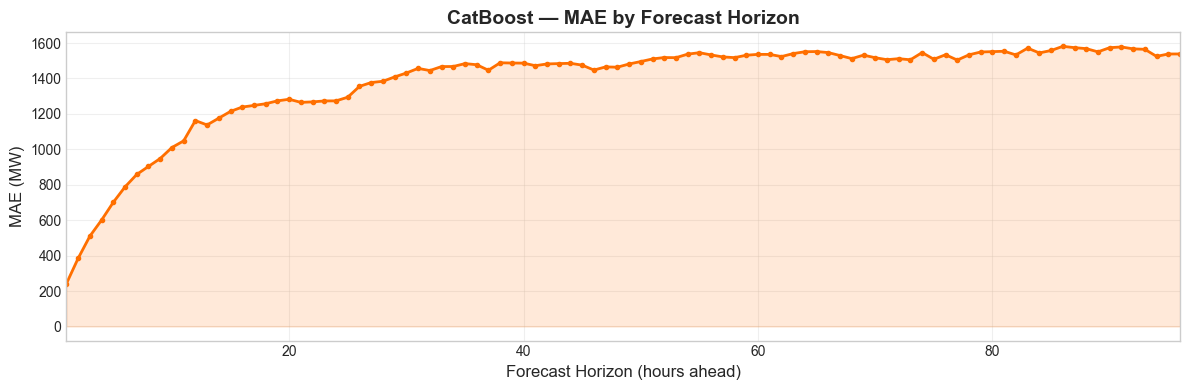

MAE at t+1:  242.1 MW
MAE at t+24: 1,273.6 MW
MAE at t+48: 1,463.7 MW
MAE at t+96: 1,538.3 MW


In [14]:
# Plot MAE by forecast horizon — shows how error grows with prediction distance
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(horizon_metrics['horizon_hour'], horizon_metrics['mae'], 
        color='#FF6F00', linewidth=2, marker='o', markersize=3)
ax.fill_between(horizon_metrics['horizon_hour'], 0, horizon_metrics['mae'], 
                alpha=0.15, color='#FF6F00')
ax.set_xlabel('Forecast Horizon (hours ahead)', fontsize=12)
ax.set_ylabel('MAE (MW)', fontsize=12)
ax.set_title('CatBoost — MAE by Forecast Horizon', fontsize=14, fontweight='bold')
ax.set_xlim(1, FORECAST_HORIZON)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"MAE at t+1:  {horizon_metrics['mae'].iloc[0]:,.1f} MW")
print(f"MAE at t+24: {horizon_metrics['mae'].iloc[23]:,.1f} MW")
print(f"MAE at t+48: {horizon_metrics['mae'].iloc[47]:,.1f} MW")
print(f"MAE at t+96: {horizon_metrics['mae'].iloc[95]:,.1f} MW")

## Step 10 — Forecast Visualization

Metrics are important, but plots reveal *patterns* that numbers alone hide.

The charts below show three randomly selected 96-hour forecast windows from the 2018 test set:
- **Blue line**: actual electricity load (with some historical context shown before the forecast origin)
- **Orange dashed line**: 96-step CatBoost forecast
- **Red vertical line**: forecast origin — everything to the right is pure prediction

**What to look for:**
- Does the model correctly track the daily on/off peak cycle over 4 days?
- Does it capture the weekday vs. weekend demand difference?
- Where do the largest errors occur — in the first few hours, or further out?
- Does error accumulate over the 96 steps, or stay roughly flat? (This is the key advantage of the direct strategy)

In [15]:
def create_timestamps(last_timestamp, freq, periods=1):
    """Generate `periods` timestamps after `last_timestamp` at a given frequency."""
    return pd.date_range(
        start=last_timestamp, freq=freq, periods=periods + 1
    ).tolist()[1:]


def plot_predictions(
    df, predictions_df, freq, timestamp_column, channel, indices, plot_context=None
):
    """
    Plot forecast windows alongside actual values.
    
    Parameters:
        df: DataFrame with actual values and a timestamp column
        predictions_df: DataFrame with 'time', prediction lists, and actual lists
        freq: Frequency string (e.g., 'h' for hourly)
        timestamp_column: Name of the timestamp column in df
        channel: Target column name
        indices: List of row indices from predictions_df to plot
        plot_context: Number of historical points to show before forecast
    """
    pred_col = f"{channel}_prediction"
    predictions_subset = [predictions_df.iloc[i] for i in indices]

    gt_df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(gt_df[timestamp_column]):
        gt_df[timestamp_column] = pd.to_datetime(gt_df[timestamp_column])
    gt_df = gt_df.set_index(timestamp_column)

    prediction_length = len(predictions_subset[0][pred_col])
    if plot_context is None:
        plot_context = 2 * prediction_length

    fig, axs = plt.subplots(len(indices), 1, figsize=(14, 3 * len(indices)), squeeze=False)
    axs = axs.flatten()

    for i, idx in enumerate(indices):
        row = predictions_subset[i]
        origin = pd.to_datetime(row[timestamp_column])
        if gt_df.index.tz is not None and origin.tzinfo is None:
            origin = origin.tz_localize(gt_df.index.tz)
        elif gt_df.index.tz is None and origin.tzinfo is not None:
            origin = origin.tz_localize(None)

        if origin not in gt_df.index:
            axs[i].set_title(f"Window {idx} — origin not found")
            continue

        loc = gt_df.index.get_loc(origin)
        ctx_start = max(0, loc - plot_context + 1)

        ts_ctx = gt_df.index[ctx_start:loc + 1]
        y_ctx = gt_df.iloc[ctx_start:loc + 1][channel].values

        act_end = min(loc + 1 + prediction_length, len(gt_df))
        ts_act = gt_df.index[loc + 1:act_end]
        y_act = gt_df.iloc[loc + 1:act_end][channel].values

        ts_pred = create_timestamps(origin, freq=freq, periods=prediction_length)
        y_pred = row[pred_col]

        # Plot
        ts_full = ts_ctx.append(ts_act) if len(ts_act) > 0 else ts_ctx
        y_full = np.concatenate([y_ctx, y_act])

        axs[i].plot(ts_full, y_full, label="Actual", color='#2196F3', linewidth=1.5)
        axs[i].plot(ts_pred[:len(y_pred)], y_pred, label="Predicted", 
                    color='#FF6F00', linewidth=1.5, linestyle='--')
        axs[i].axvline(x=origin, color='red', linestyle='-', alpha=0.7, label='Forecast Origin')
        axs[i].set_title(f"Forecast Window {idx} — Origin: {origin}", fontsize=11)
        axs[i].legend(loc='upper right', fontsize=8)
        axs[i].set_ylabel('Load (MW)')

    plt.tight_layout()
    plt.show()

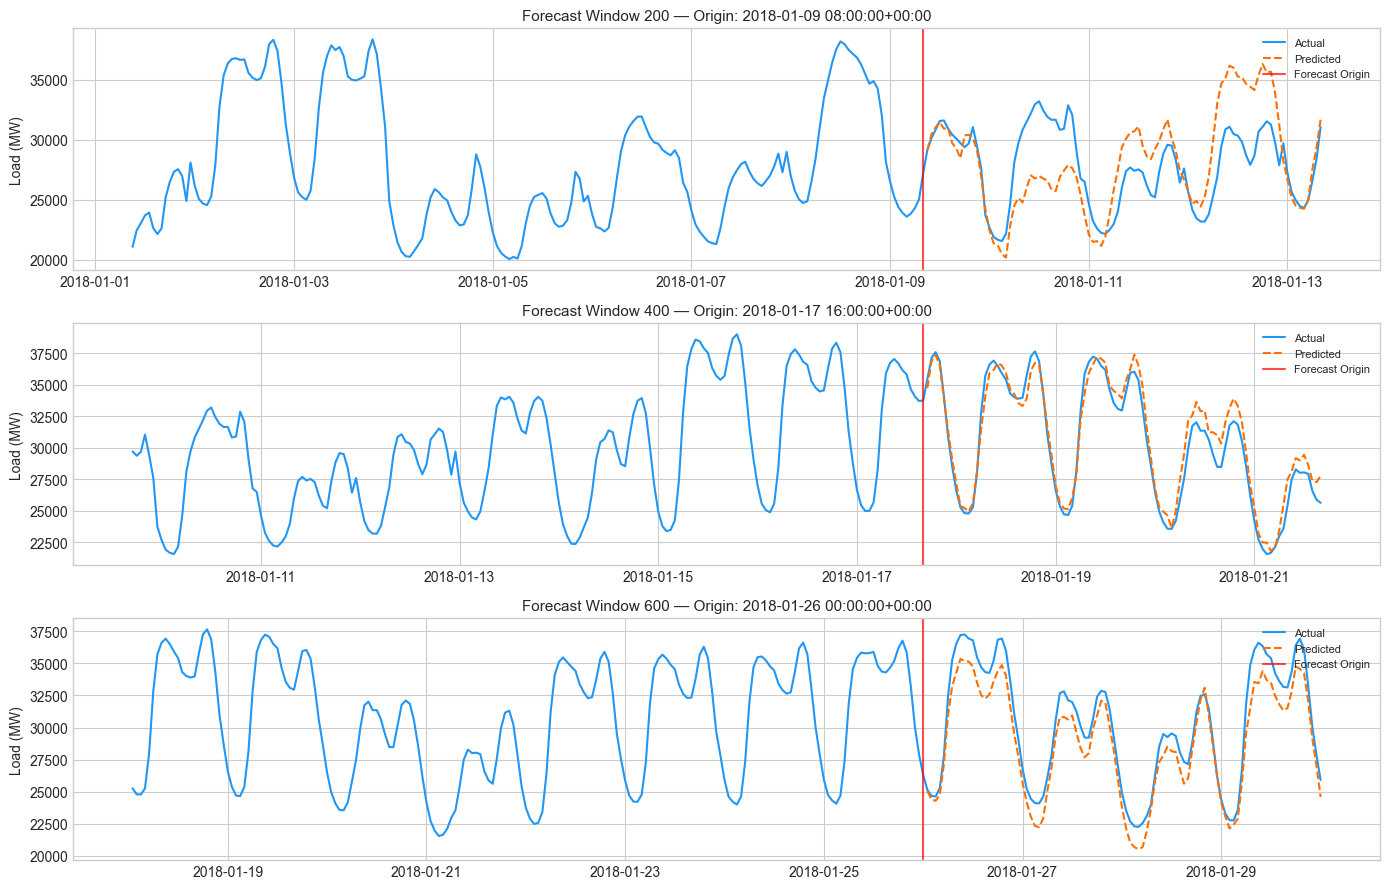

In [16]:
# Prepare test data for plotting
df_test_plot = df_test.copy().reset_index()
df_test_plot.rename(columns={'index': 'time'}, inplace=True)

# Plot 3 example forecast windows
plot_predictions(
    df=df_test_plot,
    predictions_df=forecast_df,
    freq="h",
    timestamp_column="time",
    channel=feature_name,
    indices=[200, 400, 600],
)

## Step 11 — Save Results

We pickle `forecast_df` so results can be reloaded for downstream analysis or model comparison dashboards without re-running the full training pipeline.

The saved file contains every forecast window from the 2018 test set — prediction lists and actual lists for all 96 steps — and uses the same schema as Notebooks 2 and 3, making it easy to load all three and compare them side-by-side.

In [17]:
import pickle

output_path = 'catboost_forecast.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(forecast_df, f)

print(f"Forecast saved to {output_path}")
print(f"Shape: {forecast_df.shape}")

Forecast saved to catboost_forecast.pkl
Shape: (8663, 3)


## Summary & Key Takeaways

### What we built
1. Loaded 4 years of Spanish hourly electricity data
2. Engineered 70+ temporal features from a single target column — no external weather inputs required
3. Trained 96 independent CatBoost models (one per forecast horizon) using the direct multi-output strategy
4. Evaluated on a strictly separated 2018 test year with no data leakage
5. Achieved overall MAE ≈ 1,381 MW — roughly 4–5% relative error on typical Spain grid load levels

### Concepts to remember

| Concept | Key Insight |
|---------|------------|
| Tabular regression for TS | Feature engineering replaces sequential architecture — simpler and often more accurate on structured data |
| Direct multi-output | 96 independent models → no error accumulation, better long-horizon accuracy, higher training cost |
| Cyclical encoding | sin/cos wrapping prevents the midnight discontinuity and helps trees learn circular patterns |
| Chronological split | Always split time series by time — a random split leaks future information and inflates test scores |
| Per-horizon MAE | Overall averages hide horizon-specific degradation — always plot error vs. forecast step |

### Discussion questions
1. Notice the per-horizon MAE plot — does accuracy degrade as we forecast further ahead? Why might it be relatively flat for the direct strategy?
2. What would happen if you removed the lag features and kept only the calendar features? Try modifying `features` to exclude lag columns and re-run.
3. In Step 7 we use `CatBoostRegressor(verbose=0, random_state=42)` with default hyperparameters. What knobs could you tune to improve performance?

---
*Notebook 1 of 3 — Continue to `Catboost_Tabular_WalkForward.ipynb` (Notebook 2) to compare the recursive walk-forward strategy using a single model.*